In [63]:
import numpy as np
import pandas as pd


#### Basic Cleanup + Target Transformation

In [64]:
# Load Dataset
df = pd.read_csv("dataset.csv")
df.head()

,name,description,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [65]:
# Drop rows where target is missing
df = df.dropna(subset=["price"])


#### Feature / Target Split

In [66]:
X = df.drop(columns=["price","name","description"])
y = df["price"]


In [67]:
X.head(2)

,make,model,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,Jeep,Wagoneer,2024,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,Jeep,Grand Cherokee,2024,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive


#### Automatic Column Detection

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns


#### Preprocessing Pipelines

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


In [69]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])



####  Model + Pipeline (Leakage-Safe)

In [70]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


#### Train / Test Split

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#### Train Model

In [72]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['year', 'cylinders', 'mileage', 'doors'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['make', 'model', 'engine', 'fuel', 'transmission', 'trim', 'body',
       'exterior_color', 'interior_color', 'drivetrain'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

#### Evaluation

In [73]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


RMSE: 8431.939213116586
MAE : 4653.4005038719315
R2  : 0.7671910957265209


#### Convert Back to Actual Price (Important)

In [75]:
actual_price = y_test
predicted_price = y_pred

price_df = pd.DataFrame({
    "Actual Price": actual_price,
    "Predicted Price": predicted_price
})

price_df.head()


,Actual Price,Predicted Price
200,27080.0,30737.696667
555,59255.0,55090.030000
175,54910.0,60888.633333
952,37335.0,35823.210000
66,28860.0,31005.041257


#### Save Trained Pipeline (Production Ready)

In [76]:
import joblib
joblib.dump(pipeline, "vehicle_price_pipeline.pkl")



['vehicle_price_pipeline.pkl']

### Hyperparameter Tuning (RandomizedSearchCV)

In [77]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['year', 'cylinders', 'mileage', 'doors'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHot...
      dtype='object'))])),
                                             ('model',
                                              RandomForestRegressor(n_estimators=300,
                                                                    n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [200, 300, 500]},
                   random_state=42, scoring='r2', verbose=1)

#### Best Model After Tuning

In [78]:
best_pipeline = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)


Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}


#### Evaluate Tuned Model

In [79]:
y_pred_tuned = best_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae = mean_absolute_error(y_test, y_pred_tuned)
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned RMSE:", rmse)
print("Tuned MAE :", mae)
print("Tuned R2  :", r2)


Tuned RMSE: 8461.075622498007
Tuned MAE : 5073.430539513421
Tuned R2  : 0.7655793822147209


#### Feature Importance from Pipeline

In [80]:
# Extract preprocessor
preprocessor = best_pipeline.named_steps["preprocessor"]

# Numerical features
num_features = num_cols.tolist()

# Categorical features (after one-hot encoding)
cat_features = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_cols)
)

# Combine feature names
feature_names = np.concatenate([num_features, cat_features])


#### Extract Feature Importance

In [81]:
importances = best_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)


,feature,importance
1,cylinders,0.038234
798,drivetrain_Four-wheel Drive,0.022115
261,fuel_Diesel,0.021853
2,mileage,0.021753
265,fuel_Gasoline,0.021107
24,make_Mercedes-Benz,0.020805
191,engine_24V GDI DOHC Twin Turbo,0.018285
799,drivetrain_Front-wheel Drive,0.017921
169,model_i7,0.015704
264,fuel_Electric,0.014688


#### Plot Top 15 Important Features

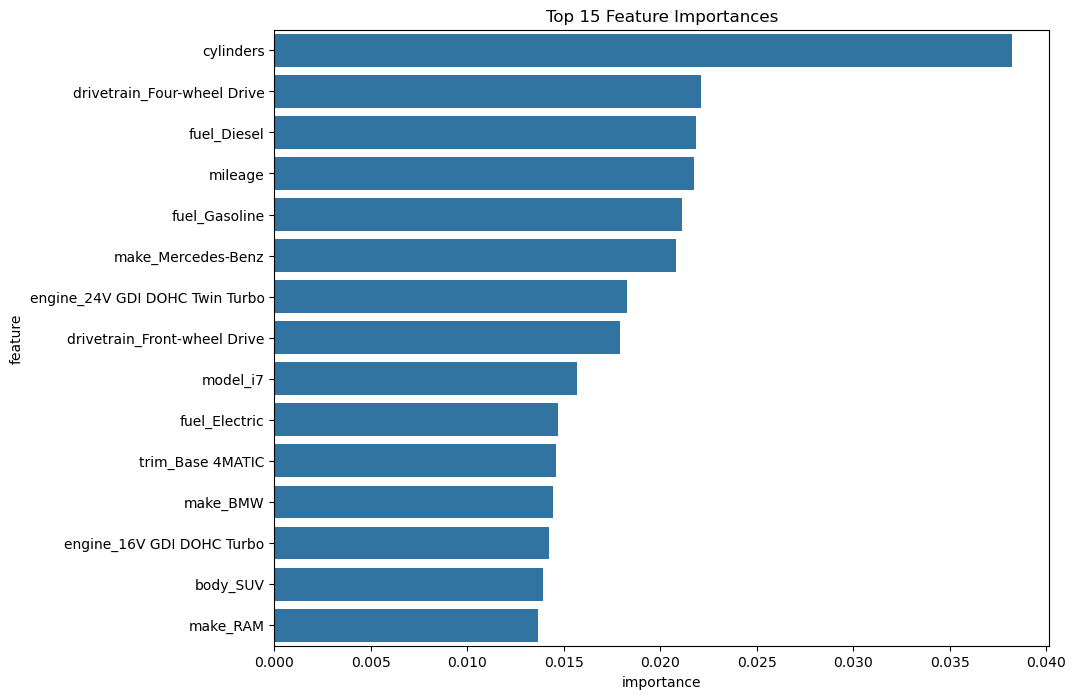

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance_df.head(15)
)
plt.title("Top 15 Feature Importances")
plt.show()
